Community 1 : [0, 1, 2, 3, 4]
Community 2 : [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


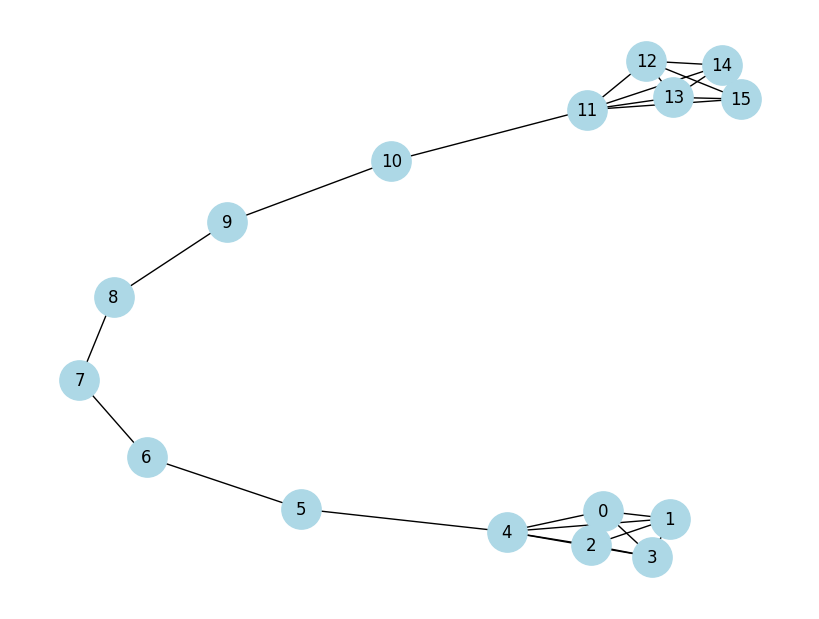

In [6]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt
def communities_brute(G):
    nodes=list(G.nodes())
    n=G.number_of_nodes()
    first_community=[]
    for i in range(1,n//2+1):
        comb=[list(x) for x in itertools.combinations(nodes,i)]
        first_community.extend(comb)
    second_community=[]
    for i in range(len(first_community)):
        l=list(set(nodes)-set(first_community[i]))
        second_community.append(l)
    num_intra_edges1=[]
    num_intra_edges2=[]
    num_inter_edges=[]
    ratio=[]
    for i in range(len(first_community)):
        num_intra_edges1.append(G.subgraph(first_community[i]).number_of_edges())
    for i in range(len(second_community)):
        num_intra_edges2.append(G.subgraph(second_community[i]).number_of_edges())
    e=G.number_of_edges()
    for i in range(len(first_community)):
        num_inter_edges.append(e-num_intra_edges1[i]-num_intra_edges2[i])
    for i in range(len(first_community)):
        if num_inter_edges[i]!=0:
            ratio.append((num_intra_edges1[i]+num_intra_edges2[i])/num_inter_edges[i])
        else:
            ratio.append(0)
    max_value=max(ratio)
    max_index=ratio.index(max_value)
    print("Community 1 :",first_community[max_index])
    print("Community 2 :",second_community[max_index])
G=nx.barbell_graph(5,6)
communities_brute(G)
plt.figure(figsize=(8,6))
nx.draw(G,with_labels=True,node_color="lightblue",node_size=800)
plt.show()